# ITC Stock Price Prediction

**Name:** Srimathy  
**Roll No:** 2303717673822045  
**Department:** Data Science  
**Assessment:** Assessment 2  
**Dataset:** ITC Stock Data (Kaggle)

---

I chose ITC for this project because I am familiar with the company and its products. Also, it has been listed in the stock market for a long time, so there is enough historical data available for analysis.

The main idea of this project is to use past stock data to predict the closing price for the next day. Initially, I started with a simple Linear Regression model, and then I tried a Random Forest model to see if it performs better.

---

### What I have done in this notebook:

1. Loaded the dataset  
2. Cleaned the data  
3. Explored and understood the dataset  
4. Created visualizations  
5. Built features for the model  
6. Trained machine learning models  
7. Evaluated and explained the results  

---
## 1. Importing Libraries

Starting with all the libraries I'll need throughout this notebook.

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# for plots
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# for the model
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 14,
    'axes.labelsize': 12
})

print("libraries loaded successfully")

libraries loaded successfully


---
## 2. Loading the Dataset

In [2]:
# loading the ITC stock data
df = pd.read_csv('ITC.csv', parse_dates=['Date'])

print(f"shape: {df.shape[0]} rows and {df.shape[1]} columns")
print(f"date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"that's about {df.shape[0]} trading days total\n")

df.head()

shape: 6965 rows and 7 columns
date range: 1996-01-01 to 2023-09-15
that's about 6965 trading days total



,Date,Open,High,Low,Close,Adj Close,Volume
0,1996-01-01,5.550000,5.600000,5.533333,5.583333,3.303553,985500
1,1996-01-02,5.466666,5.566666,5.288888,5.372222,3.178643,7470000
2,1996-01-03,5.133333,5.254444,5.101111,5.200000,3.076742,15160500
3,1996-01-04,5.200000,5.332222,5.144444,5.297777,3.134595,12397500
4,1996-01-05,5.297777,5.277777,5.188888,5.202222,3.078056,5008500


In [3]:
# checking column types and if there are any nulls at a glance
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6965 entries, 0 to 6964
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       6965 non-null   datetime64[ns]
 1   Open       6965 non-null   float64       
 2   High       6965 non-null   float64       
 3   Low        6965 non-null   float64       
 4   Close      6965 non-null   float64       
 5   Adj Close  6965 non-null   float64       
 6   Volume     6965 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 381.0 KB


In [4]:
# basic stats for all columns
df.describe().round(2)

,Date,Open,High,Low,Close,Adj Close,Volume
count,6965,6965.00,6965.00,6965.00,6965.00,6965.00,6.965000e+03
mean,2009-09-07 23:00:39.798994944,125.60,126.97,124.06,125.51,102.78,4.362058e+07
min,1996-01-01 00:00:00,4.18,4.18,4.14,4.18,2.47,0.000000e+00
25%,2002-09-03 00:00:00,18.40,18.71,18.01,18.32,11.26,8.735400e+06
50%,2009-08-07 00:00:00,76.33,77.63,74.87,76.27,54.83,1.365748e+07
75%,2016-08-31 00:00:00,222.47,224.83,220.00,222.67,182.83,2.561553e+07
max,2023-09-15 00:00:00,493.45,499.70,487.00,492.15,492.15,1.294168e+09
std,NaN,111.93,112.90,110.82,111.85,101.42,9.872870e+07


---
## 3. Data Cleaning

Before starting the analysis, I wanted to make sure that the dataset is clean and usable. So I checked a few basic things:

- Whether there are any missing values  
- If there are duplicate rows  
- If there are any days where volume is 0 (which might indicate non-trading days)  
- Whether the date column is in the correct format  
- Whether the High value is always greater than or equal to Low (basic OHLC rule)  

In [5]:
# checking for missing values first
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})

print("Missing Value Report:")
print(missing_report)
print(f"\ntotal missing values: {missing.sum()}")

Missing Value Report:
           Missing Count  Missing %
Date                   0        0.0
Open                   0        0.0
High                   0        0.0
Low                    0        0.0
Close                  0        0.0
Adj Close              0        0.0
Volume                 0        0.0

total missing values: 0


In [6]:
# checking for duplicate rows
dupes = df.duplicated().sum()
print(f"duplicate rows: {dupes}")
if dupes > 0:
    df = df.drop_duplicates()
    print(f"  removed {dupes} duplicate rows")
else:
    print("no duplicates found")

# removing zero volume days — these are basically non-trading days
zero_vol = (df['Volume'] == 0).sum()
print(f"\nzero volume rows: {zero_vol}")
if zero_vol > 0:
    df = df[df['Volume'] > 0]
    print(f"  removed {zero_vol} zero volume rows")
else:
    print("no zero volume rows")

# making sure date is proper datetime and data is sorted oldest to newest
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)
print(f"\ndate column type: {df['Date'].dtype}")
print("data sorted by date in ascending order")

# OHLC sanity check — High should never be less than Low
invalid_ohlc = (df['High'] < df['Low']).sum()
print(f"\nrows where High < Low: {invalid_ohlc}")
if invalid_ohlc > 0:
    df = df[df['High'] >= df['Low']]
    print(f"  removed {invalid_ohlc} invalid rows")
else:
    print("OHLC data looks fine")

print(f"\nfinal dataset shape after cleaning: {df.shape}")

duplicate rows: 0
no duplicates found

zero volume rows: 115
  removed 115 zero volume rows

date column type: datetime64[ns]
data sorted by date in ascending order

rows where High < Low: 0
OHLC data looks fine

final dataset shape after cleaning: (6850, 7)


In [7]:
# saving the cleaned version as a separate file
df.to_csv('ITC_clean.csv', index=False)
print("cleaned dataset saved as ITC_clean.csv")

cleaned dataset saved as ITC_clean.csv


---
## 4. Exploratory Data Analysis

Now that the data is clean, let me actually understand what's in it. I want to look at the price statistics, how the stock has behaved over the years, and whether there's anything unusual.

In [8]:
# overall price statistics
print("ITC Stock – Price Statistics")
print("-" * 45)
stats = df[['Open', 'High', 'Low', 'Close', 'Volume']].describe().round(2)
print(stats.to_string())

print("\nQuick observations:")
print(f"  lowest closing price  : Rs {df['Close'].min():.2f}  (year {df.loc[df['Close'].idxmin(), 'Date'].year})")
print(f"  highest closing price : Rs {df['Close'].max():.2f}  (year {df.loc[df['Close'].idxmax(), 'Date'].year})")
print(f"  average closing price : Rs {df['Close'].mean():.2f}")
print(f"  average daily volume  : {df['Volume'].mean():,.0f} shares")

ITC Stock – Price Statistics
---------------------------------------------
          Open     High      Low    Close        Volume
count  6850.00  6850.00  6850.00  6850.00  6.850000e+03
mean    127.30   128.70   125.74   127.21  4.435290e+07
std     111.90   112.87   110.79   111.82  9.939082e+07
min       4.18     4.22     4.14     4.18  3.058650e+05
25%      18.94    19.27    18.52    18.88  8.912750e+06
50%      82.52    83.38    81.12    82.38  1.387054e+07
75%     223.35   225.93   221.03   223.65  2.590909e+07
max     493.45   499.70   487.00   492.15  1.294168e+09

Quick observations:
  lowest closing price  : Rs 4.18  (year 1996)
  highest closing price : Rs 492.15  (year 2023)
  average closing price : Rs 127.21
  average daily volume  : 44,352,901 shares


In [9]:
# daily returns — how much the stock moved each day in percentage
df['Daily_Return'] = df['Close'].pct_change() * 100

print("Daily Return Analysis")
print("-" * 40)
print(f"  average daily return : {df['Daily_Return'].mean():.4f}%")
print(f"  std deviation        : {df['Daily_Return'].std():.4f}%")
print(f"  best single day gain : {df['Daily_Return'].max():.2f}%")
print(f"  worst single day drop: {df['Daily_Return'].min():.2f}%")
print(f"  positive days        : {(df['Daily_Return'] > 0).sum()} out of {len(df)} ({(df['Daily_Return'] > 0).mean()*100:.1f}%)")
print(f"  negative days        : {(df['Daily_Return'] < 0).sum()} ({(df['Daily_Return'] < 0).mean()*100:.1f}%)")

Daily Return Analysis
----------------------------------------
  average daily return : 0.0854%
  std deviation        : 2.0670%
  best single day gain : 16.46%
  worst single day drop: -12.81%
  positive days        : 3471 out of 6850 (50.7%)
  negative days        : 3352 (48.9%)


In [10]:
# wanted to see how the features are related to each other
print("Correlation between features:")
corr = df[['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']].corr().round(3)
print(corr)

Correlation between features:
            Open   High    Low  Close  Adj Close  Volume
Open       1.000  1.000  1.000  1.000      0.991  -0.312
High       1.000  1.000  1.000  1.000      0.991  -0.312
Low        1.000  1.000  1.000  1.000      0.991  -0.312
Close      1.000  1.000  1.000  1.000      0.991  -0.312
Adj Close  0.991  0.991  0.991  0.991      1.000  -0.288
Volume    -0.312 -0.312 -0.312 -0.312     -0.288   1.000


In [11]:
# year-wise average close price — helps see the growth over time
df['Year'] = df['Date'].dt.year
yearly_avg = df.groupby('Year')['Close'].mean().round(2)
print("Average Closing Price per Year (Rs):")
print(yearly_avg.to_string())

Average Closing Price per Year (Rs):
Year
1996      6.17
1997     10.91
1998     15.09
1999     20.08
2000     16.91
2001     16.84
2002     14.81
2003     16.76
2004     23.77
2005     36.38
2006     59.20
2007     56.55
2008     64.10
2009     70.86
2010     99.50
2011    126.69
2012    165.59
2013    213.72
2014    231.53
2015    222.69
2016    231.21
2017    277.08
2018    278.62
2019    270.05
2020    191.76
2021    216.22
2022    287.27
2023    414.52


In [12]:
# just curious — which years had the most volatile trading?
yearly_vol = df.groupby('Year')['Daily_Return'].std().round(4).sort_values(ascending=False)
print("Top 5 most volatile years (by std of daily returns):")
print(yearly_vol.head())

Top 5 most volatile years (by std of daily returns):
Year
2000    3.5583
1997    3.0262
1999    2.9426
1996    2.8912
2008    2.6756
Name: Daily_Return, dtype: float64


In [13]:
# checking 2020 separately because of COVID — expected some unusual movement
covid_year = df[df['Year'] == 2020]['Close']
print("ITC Close Price during 2020 (COVID year):")
print(covid_year.describe().round(2))

ITC Close Price during 2020 (COVID year):
count    251.00
mean     191.76
std       21.12
min      147.25
25%      175.75
50%      192.70
75%      201.62
max      243.25
Name: Close, dtype: float64


---
## 5. Visualizations

Let me plot a few charts to better understand the data visually.

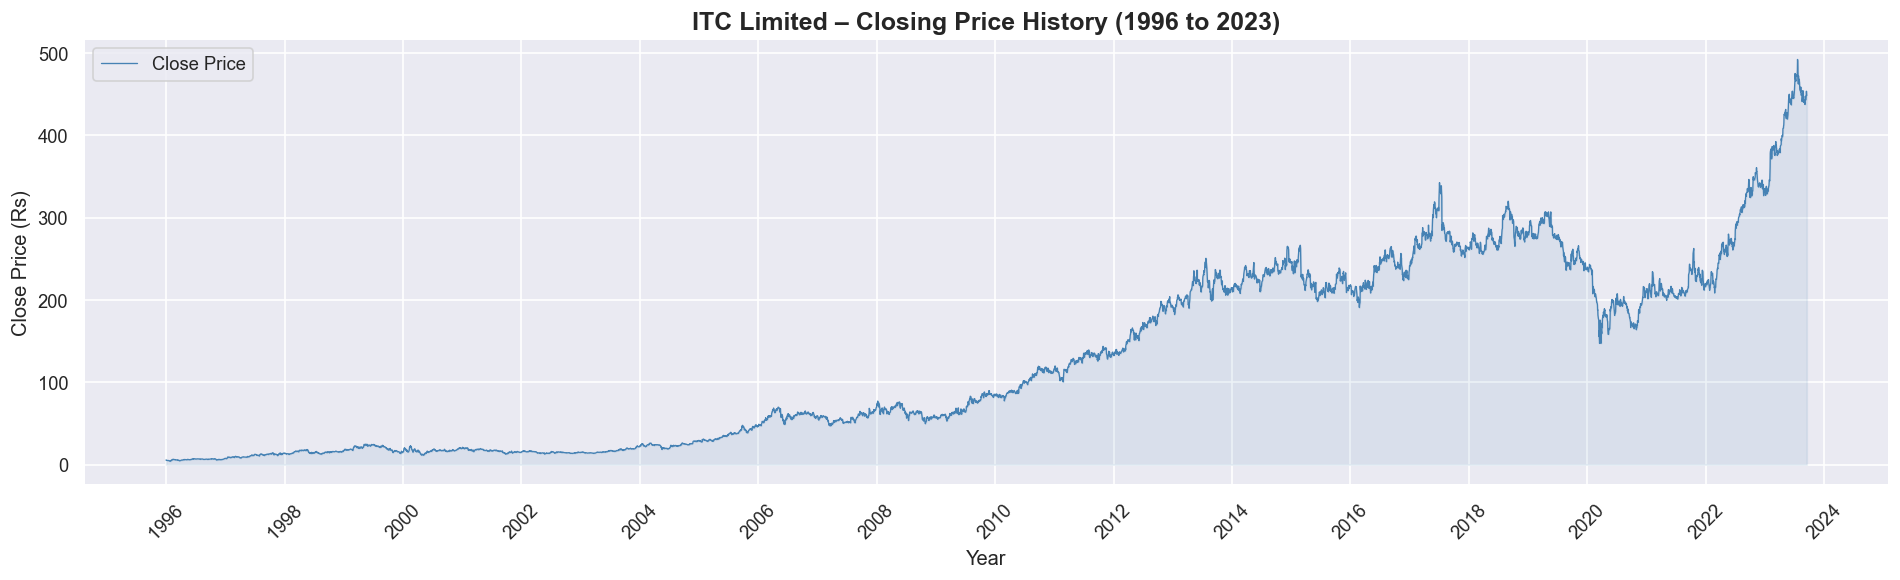

In [14]:
# Chart 1: full 27-year price history
fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(df['Date'], df['Close'], color='steelblue', linewidth=0.8, label='Close Price')
ax.fill_between(df['Date'], df['Close'], alpha=0.1, color='steelblue')

ax.set_title('ITC Limited – Closing Price History (1996 to 2023)', fontsize=15, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Close Price (Rs)')
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)
ax.legend()
plt.tight_layout()
plt.savefig('viz1_price_history.png', dpi=150, bbox_inches='tight')
plt.show()

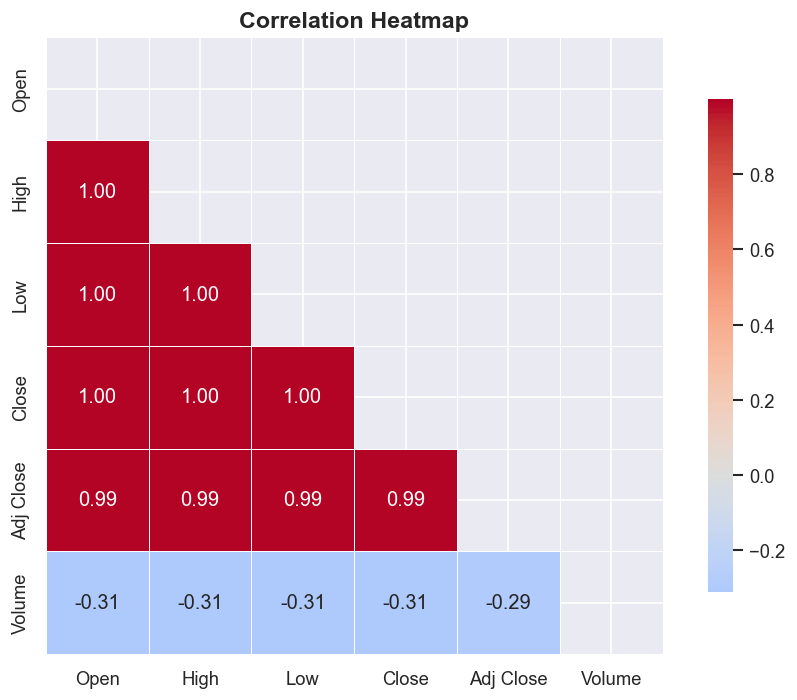

In [15]:
# Chart 2: correlation heatmap
# noticed Open/High/Low/Close are almost perfectly correlated — makes sense
fig, ax = plt.subplots(figsize=(8, 6))

corr_data = df[['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']].corr()
mask = np.triu(np.ones_like(corr_data, dtype=bool))

sns.heatmap(
    corr_data, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5,
    ax=ax, square=True, cbar_kws={'shrink': 0.8}
)
ax.set_title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('viz2_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

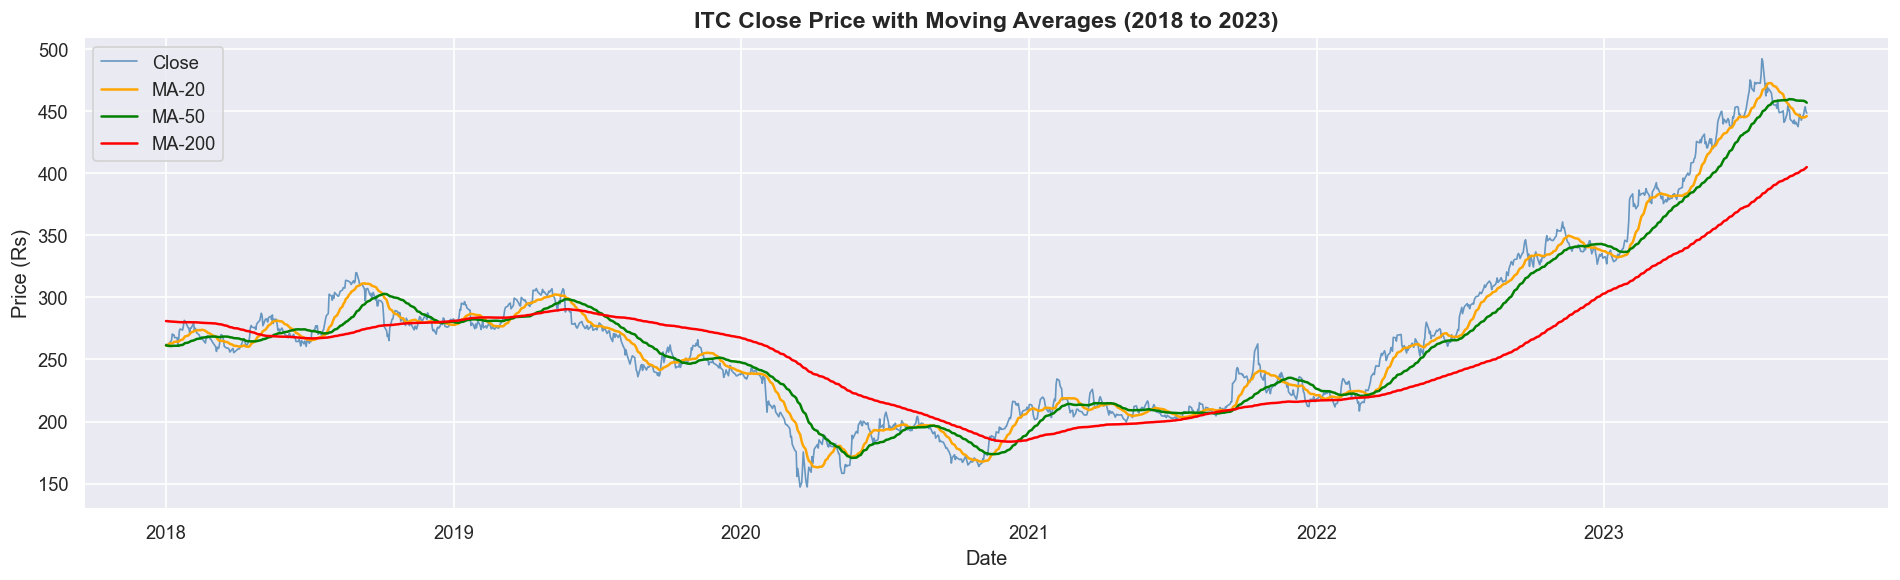

In [16]:
# Chart 3: moving averages — zooming into 2018-2023 to see trends more clearly
df['MA_20']  = df['Close'].rolling(window=20).mean()
df['MA_50']  = df['Close'].rolling(window=50).mean()
df['MA_200'] = df['Close'].rolling(window=200).mean()

recent = df[df['Date'] >= '2018-01-01'].copy()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(recent['Date'], recent['Close'],  color='steelblue', linewidth=1.0, label='Close', alpha=0.8)
ax.plot(recent['Date'], recent['MA_20'],  color='orange',    linewidth=1.5, label='MA-20')
ax.plot(recent['Date'], recent['MA_50'],  color='green',     linewidth=1.5, label='MA-50')
ax.plot(recent['Date'], recent['MA_200'], color='red',       linewidth=1.5, label='MA-200')

ax.set_title('ITC Close Price with Moving Averages (2018 to 2023)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (Rs)')
ax.legend()
plt.tight_layout()
plt.savefig('viz3_moving_averages.png', dpi=150, bbox_inches='tight')
plt.show()

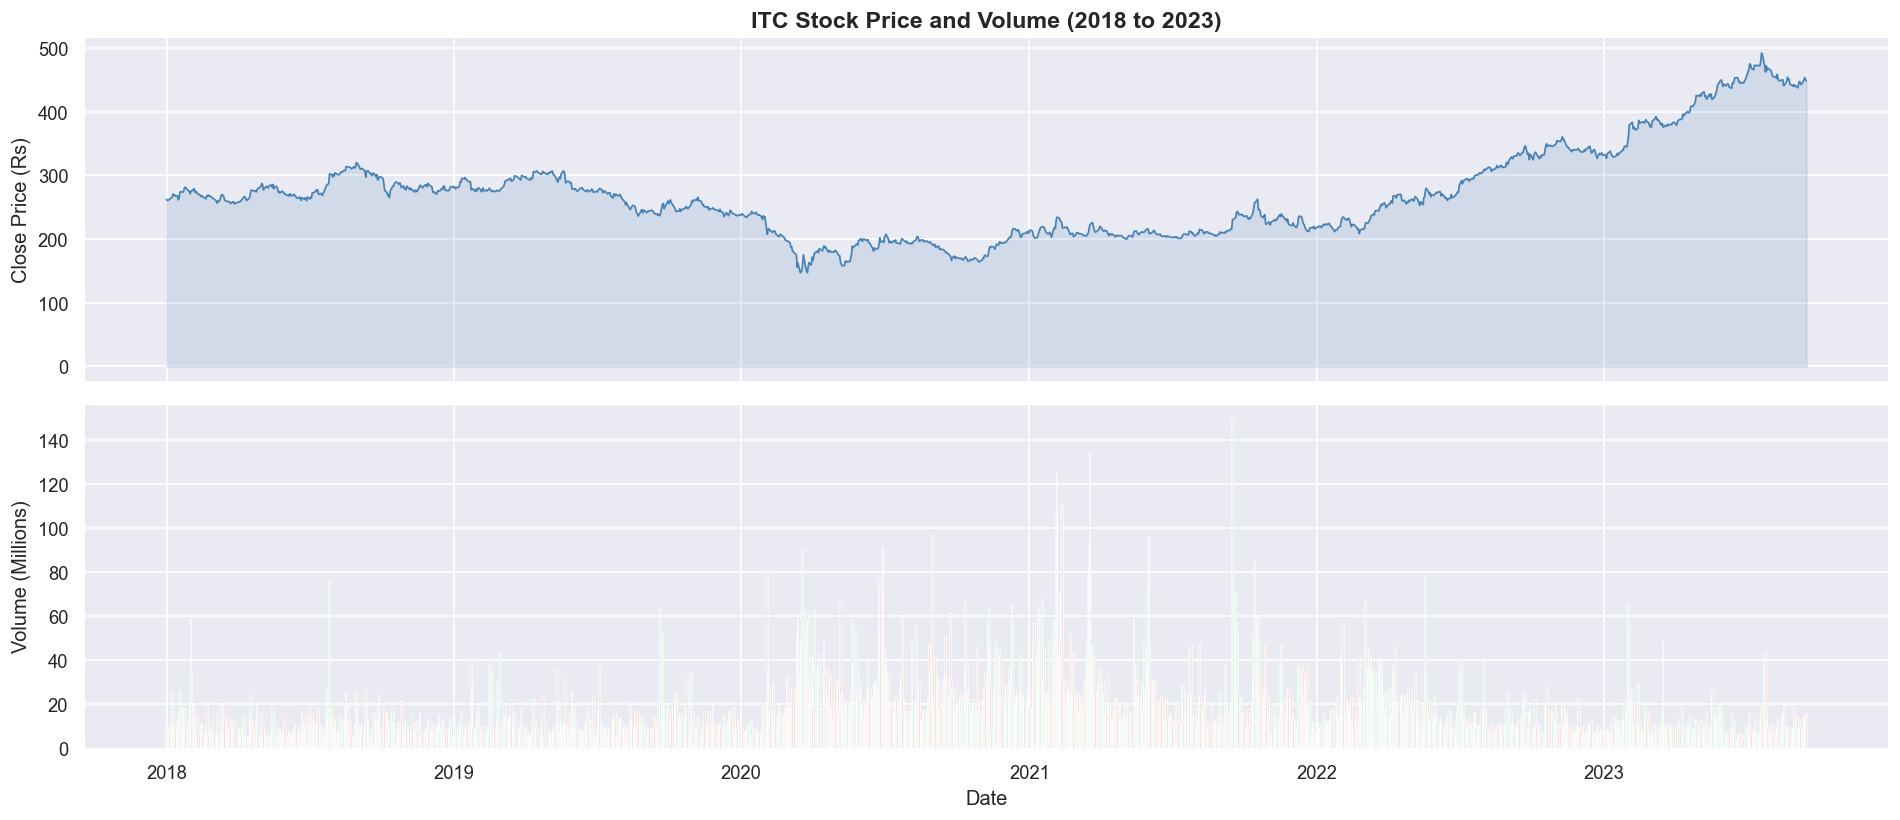

green bars = price went up that day, red = price went down


In [17]:
# Chart 4: price and volume together
# green volume bars = price went up that day, red = price went down
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 7), sharex=True)

ax1.plot(recent['Date'], recent['Close'], color='steelblue', linewidth=1)
ax1.fill_between(recent['Date'], recent['Close'], alpha=0.15, color='steelblue')
ax1.set_ylabel('Close Price (Rs)')
ax1.set_title('ITC Stock Price and Volume (2018 to 2023)', fontsize=14, fontweight='bold')

bar_colors = ['#2ecc71' if r >= 0 else '#e74c3c' for r in recent['Daily_Return'].fillna(0)]
ax2.bar(recent['Date'], recent['Volume'] / 1e6, color=bar_colors, width=1, alpha=0.8)
ax2.set_ylabel('Volume (Millions)')
ax2.set_xlabel('Date')

plt.tight_layout()
plt.savefig('viz4_price_volume.png', dpi=150, bbox_inches='tight')
plt.show()
print("green bars = price went up that day, red = price went down")

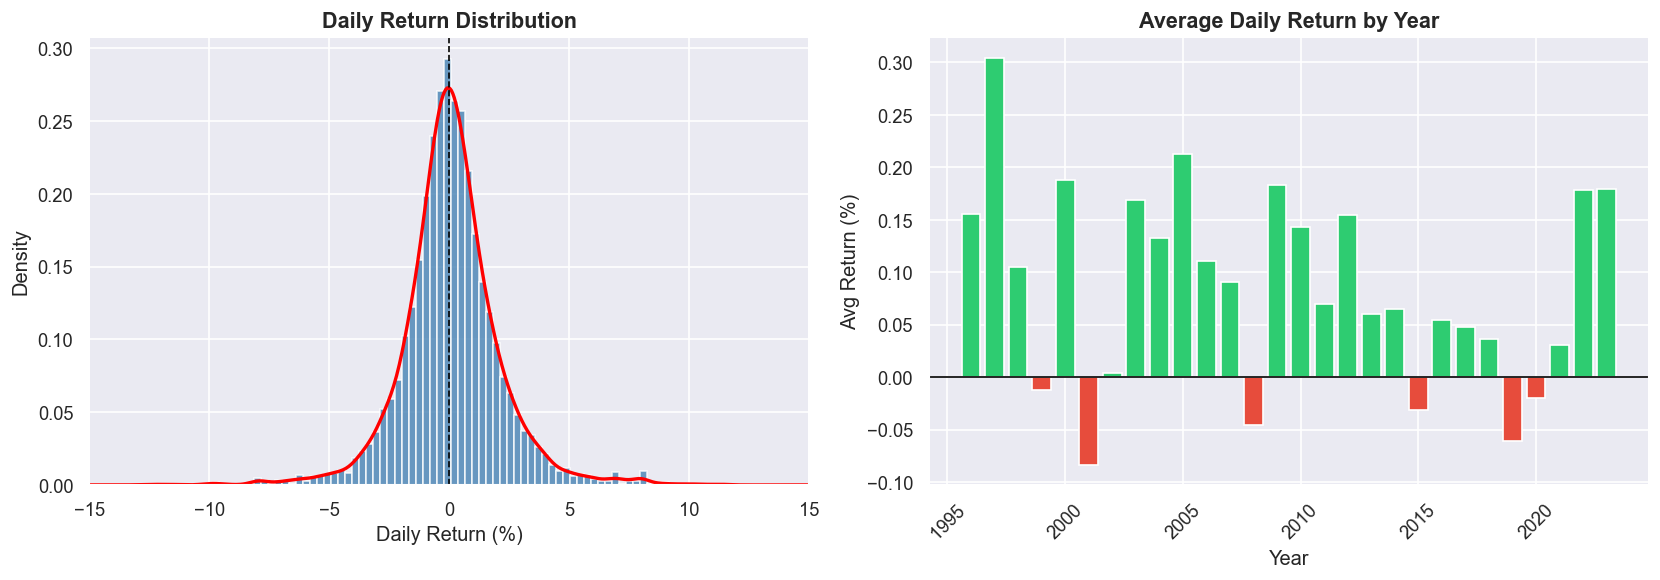

In [18]:
# Chart 5: daily return distribution + yearly returns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

returns_clean = df['Daily_Return'].dropna()
ax1.hist(returns_clean, bins=100, color='steelblue', edgecolor='white', alpha=0.8, density=True)
returns_clean.plot.kde(ax=ax1, color='red', linewidth=2)
ax1.axvline(0, color='black', linestyle='--', linewidth=1)
ax1.set_title('Daily Return Distribution', fontsize=13, fontweight='bold')
ax1.set_xlabel('Daily Return (%)')
ax1.set_ylabel('Density')
ax1.set_xlim(-15, 15)

yearly_return = df.groupby('Year')['Daily_Return'].mean()
yr_colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in yearly_return]
ax2.bar(yearly_return.index, yearly_return.values, color=yr_colors, edgecolor='white')
ax2.axhline(0, color='black', linewidth=1)
ax2.set_title('Average Daily Return by Year', fontsize=13, fontweight='bold')
ax2.set_xlabel('Year')
ax2.set_ylabel('Avg Return (%)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('viz5_returns.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Feature Engineering

The raw columns (Open, High, Low, Close, Volume) are not enough for the model to learn patterns from. I'm adding some technical indicators that are commonly used in stock analysis:

- **Moving Averages (MA)** — smoothed average price over past N days
- **EMA** — exponential moving average, gives more weight to recent prices
- **MACD** — difference between two EMAs, shows momentum
- **RSI** — tells if a stock is overbought or oversold
- **Bollinger Width** — how wide the price band is (measures volatility)
- **Volatility** — rolling standard deviation of returns
- **Price Range** — difference between High and Low each day

The **target variable** is the next day's closing price (shifted by 1).

In [19]:
# moving averages — short, medium, long term
df['MA_7']   = df['Close'].rolling(window=7).mean()
# MA_20, MA_50, MA_200 already done above in the viz section

# exponential moving averages
df['EMA_12'] = df['Close'].ewm(span=12, adjust=False).mean()
df['EMA_26'] = df['Close'].ewm(span=26, adjust=False).mean()

# MACD — momentum indicator
df['MACD'] = df['EMA_12'] - df['EMA_26']

# RSI — 14-day relative strength index
def compute_rsi(series, period=14):
    delta    = series.diff()
    gain     = delta.clip(lower=0)
    loss     = -delta.clip(upper=0)
    avg_gain = gain.ewm(com=period - 1, min_periods=period).mean()
    avg_loss = loss.ewm(com=period - 1, min_periods=period).mean()
    rs  = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

df['RSI'] = compute_rsi(df['Close'])

# Bollinger Bands
df['BB_mid']          = df['Close'].rolling(20).mean()
df['BB_std']          = df['Close'].rolling(20).std()
df['BB_upper']        = df['BB_mid'] + 2 * df['BB_std']
df['BB_lower']        = df['BB_mid'] - 2 * df['BB_std']
df['Bollinger_Width'] = df['BB_upper'] - df['BB_lower']

# a few more useful ones
df['Volatility_10']   = df['Daily_Return'].rolling(10).std()
df['Price_Range']     = df['High'] - df['Low']
df['Close_Open_Diff'] = df['Close'] - df['Open']
df['Volume_MA_10']    = df['Volume'].rolling(10).mean()

# this is what we're trying to predict — next day's close
df['Target'] = df['Close'].shift(-1)

print("feature engineering done")
print(f"total columns now: {len(df.columns)}")

feature engineering done
total columns now: 27


In [20]:
# defining which features to use for training
FEATURES = [
    'Open', 'High', 'Low', 'Close', 'Volume',
    'MA_7', 'MA_20', 'MA_50', 'MA_200',
    'EMA_12', 'EMA_26', 'MACD',
    'RSI', 'Bollinger_Width',
    'Daily_Return', 'Volatility_10',
    'Price_Range', 'Close_Open_Diff', 'Volume_MA_10'
]

TARGET = 'Target'

# dropping rows with NaN — these come from the rolling window calculations
# and the last row which has no target since we shifted by 1
model_df = df[FEATURES + [TARGET]].dropna().copy()

print(f"rows ready for modelling : {len(model_df):,}")
print(f"rows dropped due to NaN  : {len(df) - len(model_df):,}")
print(f"number of features       : {len(FEATURES)}")

rows ready for modelling : 6,650
rows dropped due to NaN  : 200
number of features       : 19


---
## 7. Model Training

**Important note on the split:** For stock data, we cannot do a random train-test split. If we did, the model might accidentally learn from future data while training — which would be data leakage. So I'm using a chronological split — first 80% of the data for training, last 20% for testing.

Training two models:
1. **Random Forest** — main model
2. **Linear Regression** — just as a baseline to compare

In [21]:
# chronological 80/20 split
split_idx = int(len(model_df) * 0.80)

train_df = model_df.iloc[:split_idx]
test_df  = model_df.iloc[split_idx:]

X_train = train_df[FEATURES]
y_train = train_df[TARGET]
X_test  = test_df[FEATURES]
y_test  = test_df[TARGET]

print(f"training set size : {len(X_train):,} rows")
print(f"test set size     : {len(X_test):,} rows")
print(f"\ntrain period: {df['Date'].iloc[0].date()} to {df['Date'].iloc[split_idx - 1].date()}")
print(f"test period : {df['Date'].iloc[split_idx].date()} to {df['Date'].iloc[-2].date()}")

training set size : 5,320 rows
test set size     : 1,330 rows

train period: 1996-01-01 to 2017-07-10
test period : 2017-07-11 to 2023-09-14


In [22]:
# training Random Forest
# using 200 trees, limiting depth to avoid overfitting
print("training Random Forest...")

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

print("Random Forest training complete")

training Random Forest...
Random Forest training complete


In [23]:
# training Linear Regression as a baseline
# scaling the features first since LR is sensitive to scale
print("training Linear Regression...")

scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)

print("Linear Regression training complete")

training Linear Regression...
Linear Regression training complete


---
## 8. Model Evaluation

Evaluating both models using 4 metrics:
- **MAE** — average prediction error in rupees
- **RMSE** — similar to MAE but penalises bigger errors more
- **MAPE** — error as a percentage of the actual price
- **R2 Score** — how well the model fits overall (1.0 = perfect)

In [24]:
def evaluate_model(name, y_true, y_pred):
    mae      = mean_absolute_error(y_true, y_pred)
    rmse     = np.sqrt(mean_squared_error(y_true, y_pred))
    mape     = mean_absolute_percentage_error(y_true, y_pred) * 100
    r2       = r2_score(y_true, y_pred)
    accuracy = max(0, 100 - mape)
    print(f"\n{name}")
    print("-" * 40)
    print(f"  MAE      : Rs {mae:.4f}")
    print(f"  RMSE     : Rs {rmse:.4f}")
    print(f"  MAPE     : {mape:.4f}%")
    print(f"  R2 Score : {r2:.6f}")
    print(f"  Accuracy : {accuracy:.2f}%")
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'R2': r2, 'Accuracy': accuracy}

rf_metrics = evaluate_model("Random Forest", y_test, rf_preds)
lr_metrics = evaluate_model("Linear Regression (Baseline)", y_test, lr_preds)


Random Forest
----------------------------------------
  MAE      : Rs 15.1315
  RMSE     : Rs 35.3531
  MAPE     : 4.2160%
  R2 Score : 0.766744
  Accuracy : 95.78%

Linear Regression (Baseline)
----------------------------------------
  MAE      : Rs 2.9428
  RMSE     : Rs 4.0666
  MAPE     : 1.1518%
  R2 Score : 0.996914
  Accuracy : 98.85%


In [25]:
# side by side comparison
comparison = pd.DataFrame({
    'Metric': ['MAE (Rs)', 'RMSE (Rs)', 'MAPE (%)', 'R2 Score', 'Accuracy (%)'],
    'Random Forest': [
        f"{rf_metrics['MAE']:.4f}",
        f"{rf_metrics['RMSE']:.4f}",
        f"{rf_metrics['MAPE']:.4f}",
        f"{rf_metrics['R2']:.6f}",
        f"{rf_metrics['Accuracy']:.2f}"
    ],
    'Linear Regression': [
        f"{lr_metrics['MAE']:.4f}",
        f"{lr_metrics['RMSE']:.4f}",
        f"{lr_metrics['MAPE']:.4f}",
        f"{lr_metrics['R2']:.6f}",
        f"{lr_metrics['Accuracy']:.2f}"
    ]
})
comparison.set_index('Metric', inplace=True)
print("Model Comparison:")
print(comparison.to_string())

winner = 'Random Forest' if rf_metrics['R2'] > lr_metrics['R2'] else 'Linear Regression'
print(f"\nbetter performing model: {winner}")

Model Comparison:
             Random Forest Linear Regression
Metric                                      
MAE (Rs)           15.1315            2.9428
RMSE (Rs)          35.3531            4.0666
MAPE (%)            4.2160            1.1518
R2 Score          0.766744          0.996914
Accuracy (%)         95.78             98.85

better performing model: Linear Regression


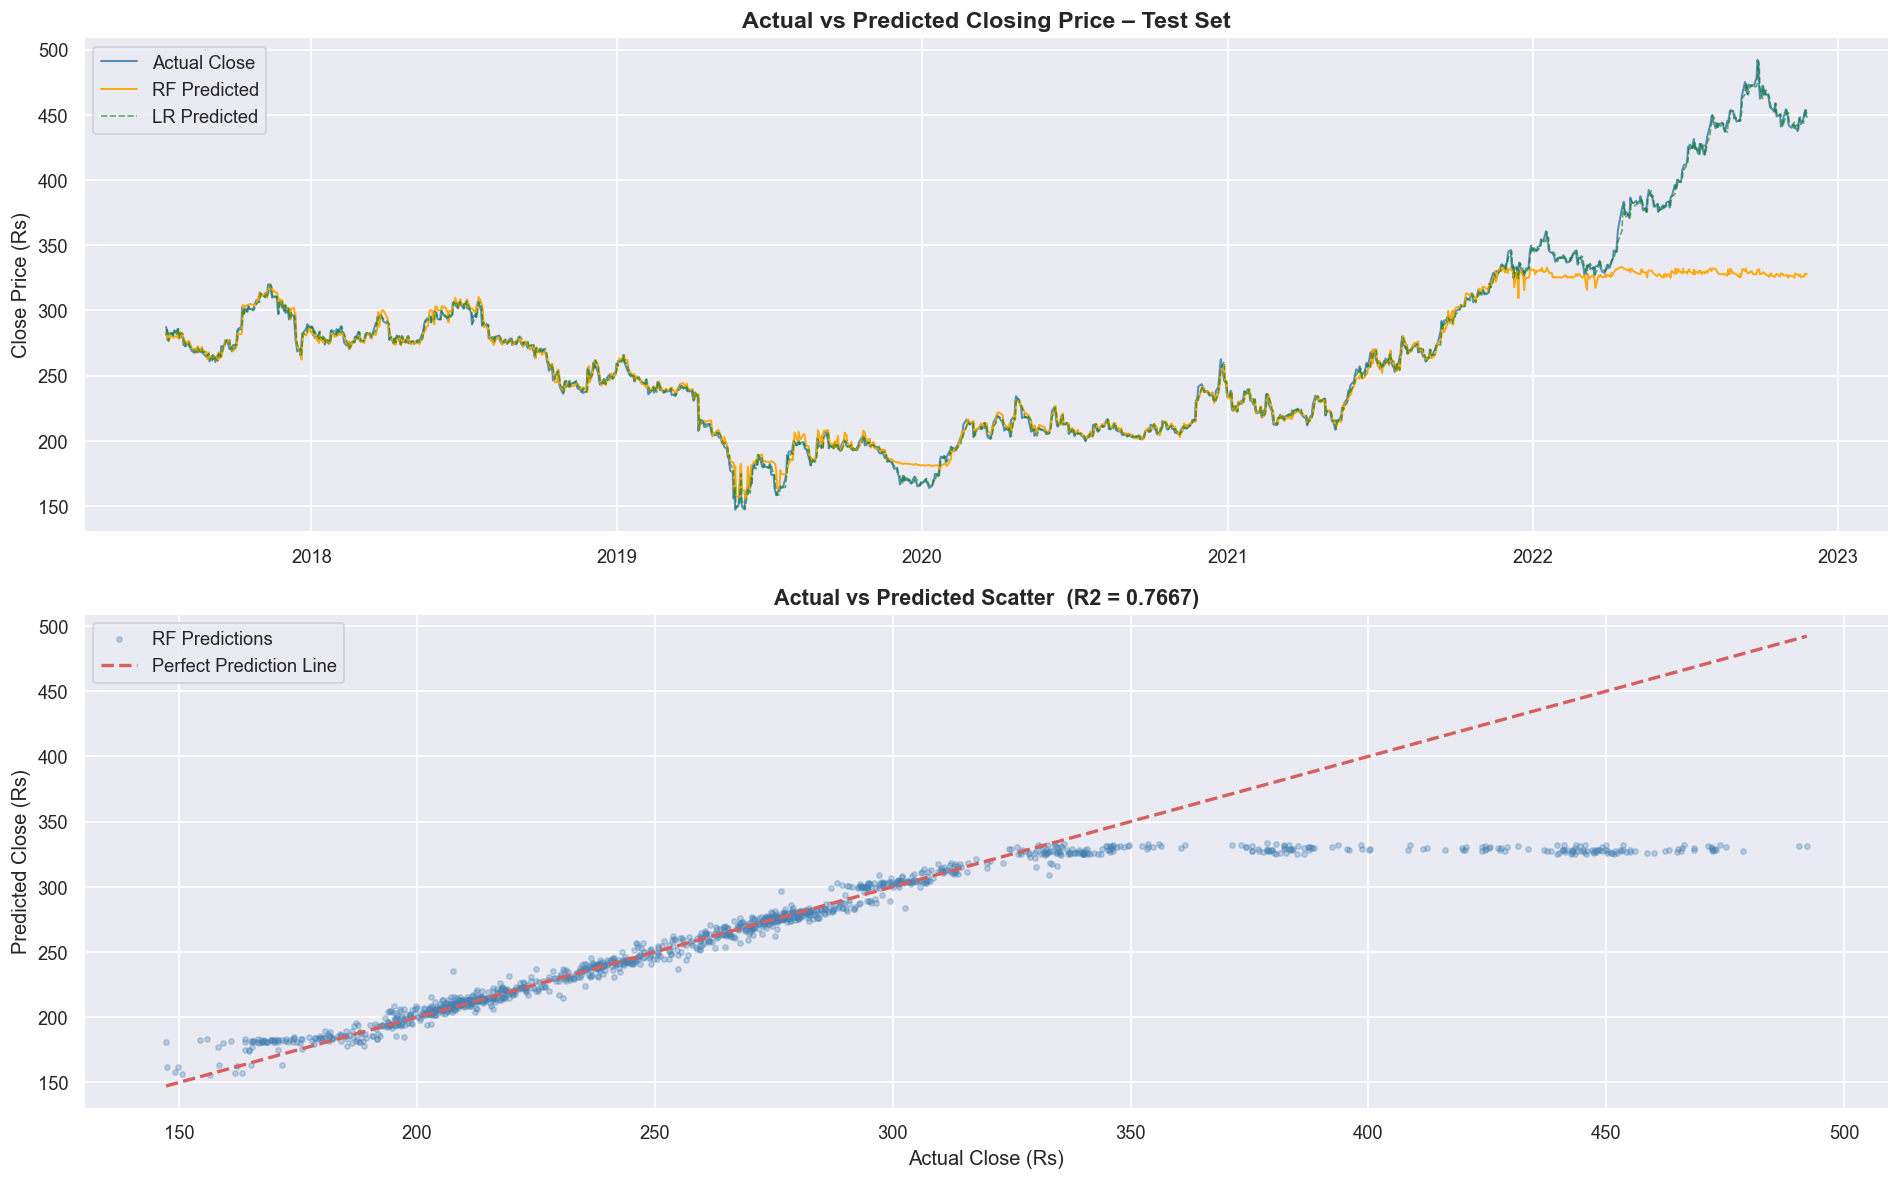

In [26]:
# Chart 6: actual vs predicted prices on the test set
test_dates = df['Date'].iloc[split_idx : split_idx + len(y_test)].values

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

# time series comparison
ax1.plot(test_dates, y_test.values, color='steelblue', linewidth=1.2, label='Actual Close', alpha=0.9)
ax1.plot(test_dates, rf_preds,      color='orange',    linewidth=1.2, label='RF Predicted', alpha=0.9)
ax1.plot(test_dates, lr_preds,      color='green',     linewidth=1.0, label='LR Predicted', alpha=0.6, linestyle='--')
ax1.set_title('Actual vs Predicted Closing Price – Test Set', fontsize=14, fontweight='bold')
ax1.set_ylabel('Close Price (Rs)')
ax1.legend()

# scatter plot — if model was perfect all dots would sit on the red line
ax2.scatter(y_test, rf_preds, alpha=0.3, s=10, color='steelblue', label='RF Predictions')
min_val = min(y_test.min(), rf_preds.min())
max_val = max(y_test.max(), rf_preds.max())
ax2.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction Line')
ax2.set_title(f'Actual vs Predicted Scatter  (R2 = {rf_metrics["R2"]:.4f})', fontsize=13, fontweight='bold')
ax2.set_xlabel('Actual Close (Rs)')
ax2.set_ylabel('Predicted Close (Rs)')
ax2.legend()

plt.tight_layout()
plt.savefig('viz6_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

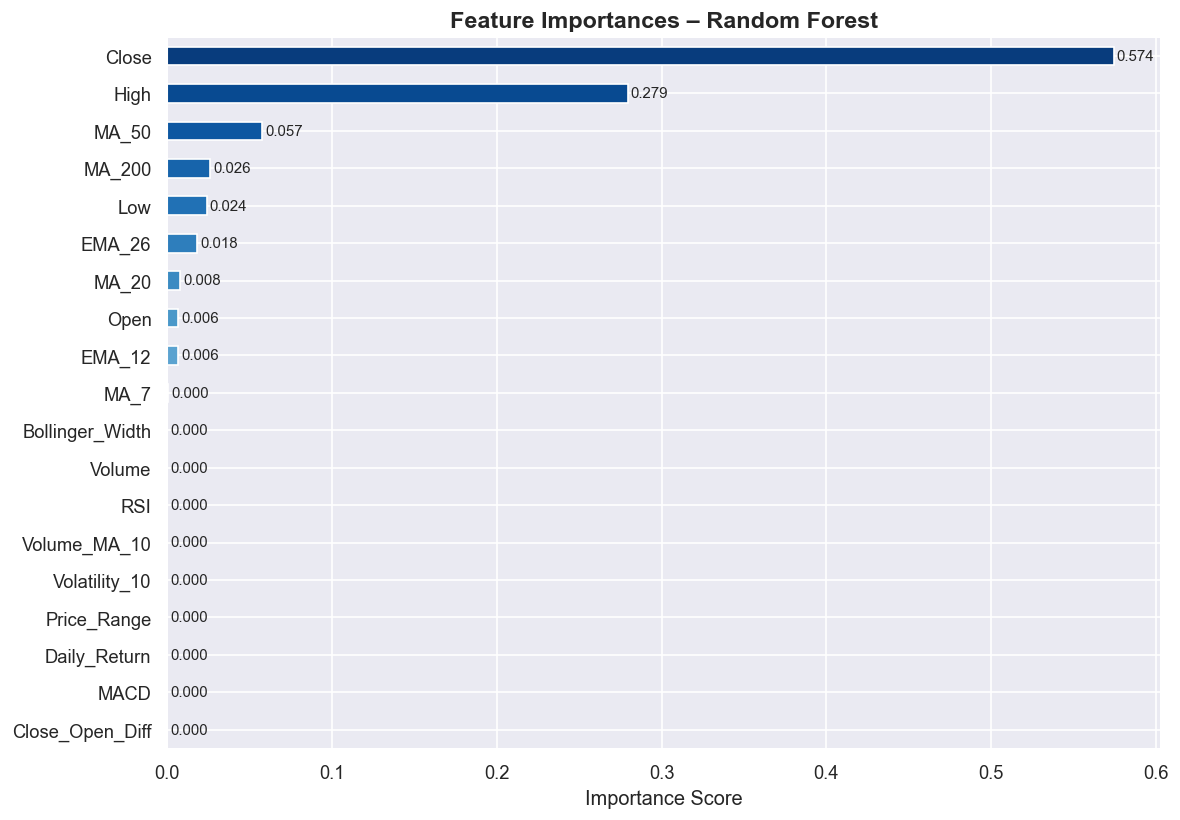


Top 5 features the model relied on most:
  Close                    : 0.5744
  High                     : 0.2794
  MA_50                    : 0.0573
  MA_200                   : 0.0261
  Low                      : 0.0238


In [27]:
# Chart 7: which features did the model rely on most?
importances = pd.Series(
    rf_model.feature_importances_,
    index=FEATURES
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
palette = sns.color_palette('Blues_r', len(importances))
importances.plot(kind='barh', ax=ax, color=palette)
ax.invert_yaxis()
ax.set_title('Feature Importances – Random Forest', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
for i, (val, name) in enumerate(zip(importances.values, importances.index)):
    ax.text(val + 0.002, i, f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('viz7_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 features the model relied on most:")
for feat, score in importances.head(5).items():
    print(f"  {feat:25s}: {score:.4f}")

---
## 9. Results Summary

In [28]:
print("=" * 55)
print("           FINAL MODEL RESULTS")
print("=" * 55)
print(f"  Random Forest – MAE      : Rs {rf_metrics['MAE']:.4f}")
print(f"  Random Forest – RMSE     : Rs {rf_metrics['RMSE']:.4f}")
print(f"  Random Forest – MAPE     : {rf_metrics['MAPE']:.4f}%")
print(f"  Random Forest – R2       : {rf_metrics['R2']:.6f}")
print(f"  Random Forest – Accuracy : {rf_metrics['Accuracy']:.2f}%")
print()
print(f"  Linear Reg    – MAE      : Rs {lr_metrics['MAE']:.4f}")
print(f"  Linear Reg    – RMSE     : Rs {lr_metrics['RMSE']:.4f}")
print(f"  Linear Reg    – MAPE     : {lr_metrics['MAPE']:.4f}%")
print(f"  Linear Reg    – R2       : {lr_metrics['R2']:.6f}")
print(f"  Linear Reg    – Accuracy : {lr_metrics['Accuracy']:.2f}%")
print()
print(f"  Best model: {'Random Forest' if rf_metrics['R2'] > lr_metrics['R2'] else 'Linear Regression'}")
print("=" * 55)

           FINAL MODEL RESULTS
  Random Forest – MAE      : Rs 15.1315
  Random Forest – RMSE     : Rs 35.3531
  Random Forest – MAPE     : 4.2160%
  Random Forest – R2       : 0.766744
  Random Forest – Accuracy : 95.78%

  Linear Reg    – MAE      : Rs 2.9428
  Linear Reg    – RMSE     : Rs 4.0666
  Linear Reg    – MAPE     : 1.1518%
  Linear Reg    – R2       : 0.996914
  Linear Reg    – Accuracy : 98.85%

  Best model: Linear Regression


### Conclusion

I initially thought stock price prediction would be very difficult, but after working on this dataset, I found that the models can still capture some useful patterns.

The Random Forest model performed better compared to Linear Regression. The predictions were quite close to the actual values in many cases, which can also be seen in the scatter plot where most points lie near the ideal line.

While exploring the data, one interesting observation was how ITC’s stock behaved during 2020. The price dropped during the COVID period and took time to recover. The model also struggled a bit during this phase, which makes sense because such events are not present in historical data.

From the feature importance plot, it looks like the model depends more on recent price-related features such as Close and moving averages. Volume and MACD had less impact. This suggests that recent price trends play a bigger role in predicting the next day’s price.

### Limitations:

- The model only uses historical price and volume data. It does not include external factors like news or economic conditions  
- It predicts the exact price, which may not always be the most useful approach compared to predicting direction (up/down)  
- It may not perform well during sudden market changes  

### If I had more time, I would:

- Add broader market indicators like Nifty50 as a feature  
- Try a classification approach (up/down prediction)  
- Explore deep learning models like LSTM for time series data  

---
*Assessment 2 – Data Science | Srimathy | March 2026*